<h1 style='color: green; font-size: 36px; font-weight: bold;'>Data Science  - Regresión Lineal</h1>

# <font color='red' style='font-size: 30px;'>Conociendo el Dataset</font>
<hr style='border: 2px solid red;'>

## Importando bibliotecas

https://matplotlib.org/

https://pandas.pydata.org/

http://www.numpy.org/

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Bibliotecas opcionales

https://docs.python.org/3/library/warnings.html

In [2]:
import warnings

warnings.filterwarnings('ignore') #warnings.filterwarnings(action='once')

## El Dataset y el Proyecto
<hr>

### Fuente: https://www.kaggle.com/dongeorge/beer-consumption-sao-paulo

### Descripción:
<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>La cerveza es una de las bebidas más democráticas y consumidas del mundo. No sin razón, es perfecta para casi todas las situaciones, desde el happy hour hasta las grandes fiestas de bodas.</p>

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>El objetivo de este proyecto es estimar un modelo de <b>Machine Learning</b> utilizando la técnica de <b>Regresión Lineal</b> para demostrar los impactos de las variables disponibles en este dataset sobre el consumo de cerveza (Y). Al final del proyecto, tendremos un modelo de predicción para el consumo medio de cerveza según los inputs de un conjunto de variables (X's).</p>


<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Los datos (muestra) fueron recolectados en São Paulo - Brasil, en un área universitaria, donde hay algunas fiestas con grupos de estudiantes de 18 a 28 años (en media).</p>

### Datos:
<ul style='font-size: 18px; line-height: 2; text-align: justify;'>
    <li><b>fecha</b> - Fecha</li>
    <li><b>temp_media</b> - Temperatura Media (°C)</li>
    <li><b>temp_min</b> - Temperatura Mínima (°C)</li>
    <li><b>temp_max</b> - Temperatura Máxima (°C)</li>
    <li><b>lluvia</b> - Precipitación (mm)</li>
    <li><b>fds</b> - Fin de Semana (1 = Sí; 0 = No)</li>
    <li><b>consumo</b> - Consumo de Cerveza (litros)</li>
</ul>

## Lectura de los datos

In [3]:
datos= pd.read_csv('Consumo_cerveza.csv',sep=';')

## Ver los datos

In [4]:
datos

,fecha,temp_media,temp_min,temp_max,lluvia,fds,consumo
0,01/01/2015,27.30,23.9,32.5,0.0,0,25461
1,02/01/2015,27.02,24.5,33.5,0.0,0,28972
2,03/01/2015,24.82,22.4,29.9,0.0,1,30814
3,04/01/2015,23.98,21.5,28.6,1.2,1,29799
4,05/01/2015,23.82,21.0,28.3,0.0,0,28900
...,...,...,...,...,...,...,...
360,27/12/2015,24.00,21.1,28.2,13.6,1,32307
361,28/12/2015,22.64,21.1,26.7,0.0,0,26095
362,29/12/2015,21.68,20.3,24.1,10.3,0,22309
363,30/12/2015,21.38,19.3,22.4,6.3,0,20467


## Verificando el tamaño del dataset

In [5]:
datos.shape

(365, 7)

# <font color='red' style='font-size: 30px;'>Analisis preliminar</font>

<hr style='border: 2px solid red;'>

## Estadísticos descriptivos

In [6]:
# descripcion de los valores en nuestros datos
datos.describe().round(2)

,temp_media,temp_min,temp_max,lluvia,fds,consumo
count,365.00,365.00,365.00,365.00,365.00,365.00
mean,21.23,17.46,26.61,5.20,0.28,25401.37
std,3.18,2.83,4.32,12.42,0.45,4399.14
min,12.90,10.60,14.50,0.00,0.00,14343.00
25%,19.02,15.30,23.80,0.00,0.00,22008.00
50%,21.38,17.90,26.90,0.00,0.00,24867.00
75%,23.28,19.60,29.40,3.20,1.00,28631.00
max,28.86,24.50,36.50,94.80,1.00,37937.00


## Matriz de correlación

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>El <b> coeficiente de correlación </b> es una medida de asociación lineal entre dos variables y su valor está entre <b> -1 </b> y <b> +1 </b>, dónde <b> - 1 </b> indica asociación negativa perfecta y <b> +1 </b> indica asociación positiva perfecta.</p>

In [7]:
datos.corr(numeric_only=True).round(4)

,temp_media,temp_min,temp_max,lluvia,fds,consumo
temp_media,1.0000,0.8628,0.9225,0.0244,-0.0508,0.5746
temp_min,0.8628,1.0000,0.6729,0.0986,-0.0595,0.3925
temp_max,0.9225,0.6729,1.0000,-0.0493,-0.0403,0.6427
lluvia,0.0244,0.0986,-0.0493,1.0000,0.0016,-0.1938
fds,-0.0508,-0.0595,-0.0403,0.0016,1.0000,0.5060
consumo,0.5746,0.3925,0.6427,-0.1938,0.5060,1.0000


# <font color='red' style='font-size: 30px;'>Comportamiento de la variable dependiente (Y)</font>
<hr style='border: 2px solid red;'>

# Análisis grafico

## Dibujando el plot de la variable *dependiente* (y)
https://pandas.pydata.org/pandas-docs/stable/visualization.html

Text(0.5, 0, 'Días')

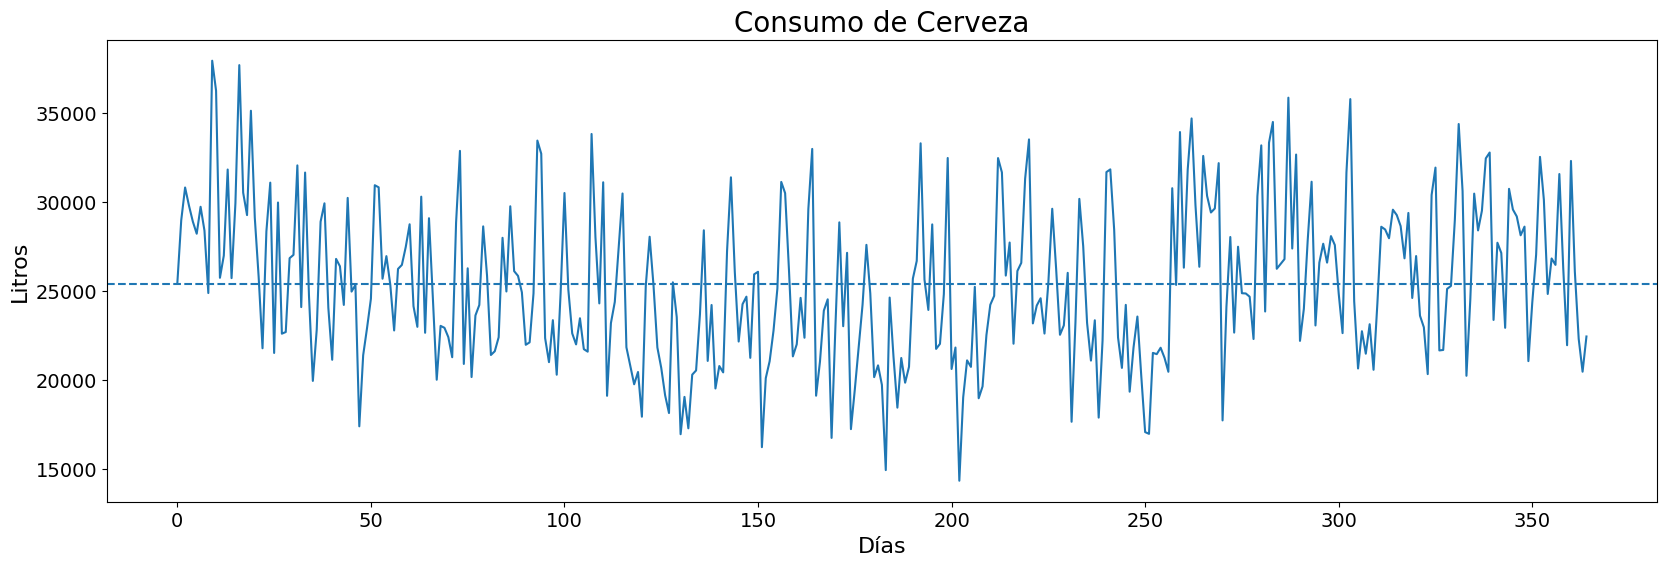

In [8]:
fig, ax=plt.subplots(figsize=(20,6))

ax=datos['consumo'].plot(fontsize=14)
ax.axhline(y=np.mean(datos['consumo']),ls='--')
ax.set_title('Consumo de Cerveza',fontsize=20)
ax.set_ylabel('Litros', fontsize=16)
ax.set_xlabel('Días', fontsize=16)

# <font color='red' style='font-size: 30px;'>Box Plot (Diagrama de caja)</font>



<hr style='border: 2px solid red;'>

<img width='700px' src='https://caelum-online-public.s3.amazonaws.com/ESP-1774-regresion-lineal/Box-Plot.png'>

## Importando la biblioteca seaborn
https://seaborn.pydata.org/
<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Seaborn es una biblioteca de visualización de datos de Python basada en matplotlib. Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos.</p>

In [9]:
import seaborn as sns

## Box plot de la variable *dependiente* (y)

https://seaborn.pydata.org/generated/seaborn.boxplot.html?highlight=boxplot#seaborn.boxplot

<Axes: title={'center': 'Consumo de Cerveza'}, ylabel='Litros'>

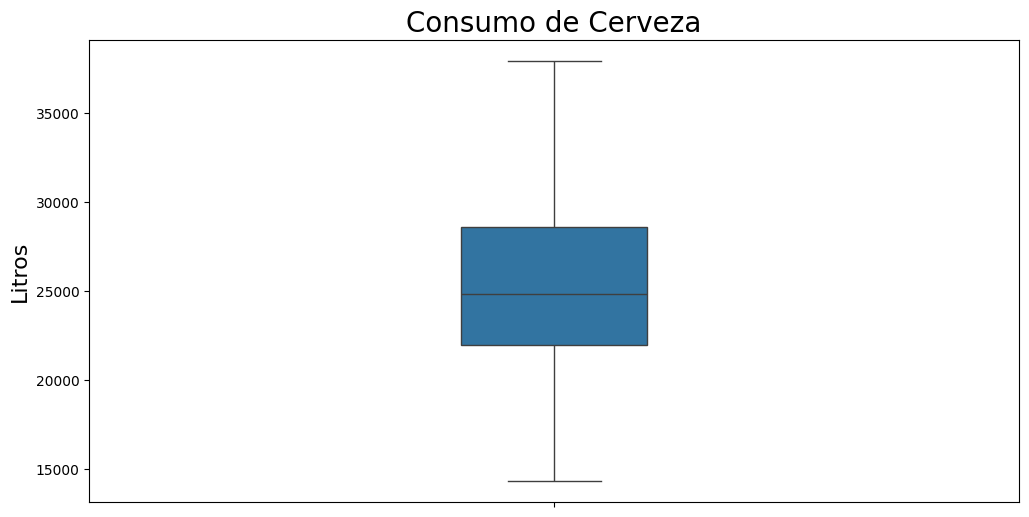

In [10]:
ax=sns.boxplot(data=datos['consumo'],orient='v',width=0.2)
ax.figure.set_size_inches(12,6)
ax.set_title('Consumo de Cerveza',fontsize=20)
ax.set_ylabel('Litros', fontsize=16)
ax

# <font color='red' style='font-size: 30px;'>Box Plot con Dos Variables</font>
<hr style='border: 2px solid red;'>

## Analizar la variable *dependiente* (y) de acuerdo con una característica dada

<Axes: title={'center': 'Consumo de Cerveza'}, xlabel='Fin de Semana', ylabel='Litros'>

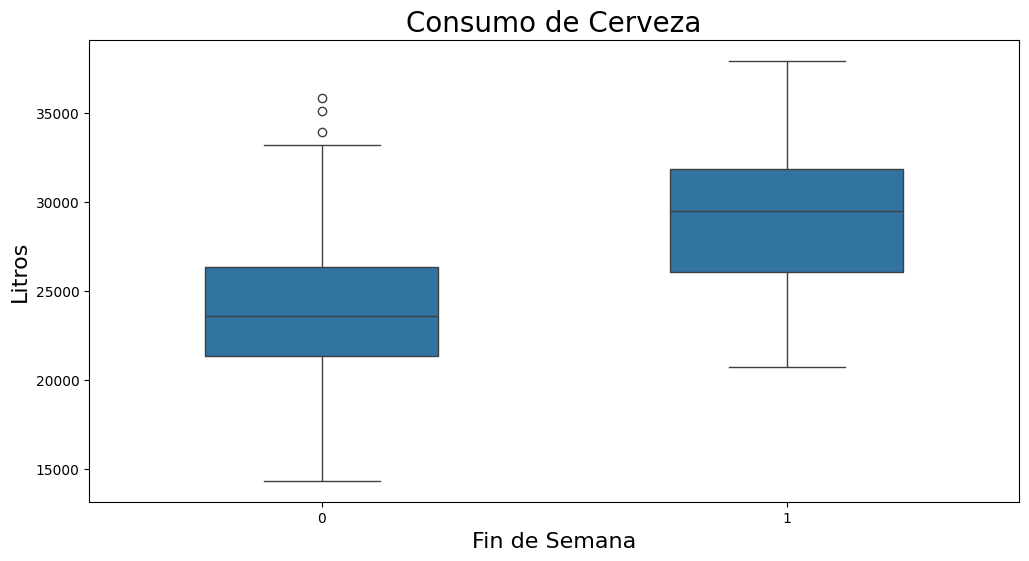

In [11]:
ax=sns.boxplot(y='consumo',x='fds',data=datos,orient='v',width=0.5)
ax.figure.set_size_inches(12,6)
ax.set_title('Consumo de Cerveza',fontsize=20)
ax.set_ylabel('Litros', fontsize=16)
ax.set_xlabel('Fin de Semana', fontsize=16)
ax

## Configuración de color y estilo de la biblioteca *seaborn*

### Control de estilo

> ####  API
> https://seaborn.pydata.org/api.html#style-api

> #### Tutorial
> https://seaborn.pydata.org/tutorial/aesthetics.html#aesthetics-tutorial

### Paleta de colores

> #### API
> https://seaborn.pydata.org/api.html#palette-api

> #### Tutorial
> https://seaborn.pydata.org/tutorial/color_palettes.html#palette-tutorial

In [12]:
# palette -> Accent, Accent_r, Blues, Blues_r, BrBG, BrBG_r, BuGn, BuGn_r, BuPu, BuPu_r, CMRmap, CMRmap_r, Dark2, Dark2_r, GnBu, GnBu_r, Greens, Greens_r, Greys, Greys_r, OrRd, OrRd_r, Oranges, Oranges_r, PRGn, PRGn_r, Paired, Paired_r, Pastel1, Pastel1_r, Pastel2, Pastel2_r, PiYG, PiYG_r, PuBu, PuBuGn, PuBuGn_r, PuBu_r, PuOr, PuOr_r, PuRd, PuRd_r, Purples, Purples_r, RdBu, RdBu_r, RdGy, RdGy_r, RdPu, RdPu_r, RdYlBu, RdYlBu_r, RdYlGn, RdYlGn_r, Reds, Reds_r, Set1, Set1_r, Set2, Set2_r, Set3, Set3_r, Spectral, Spectral_r, Wistia, Wistia_r, YlGn, YlGnBu, YlGnBu_r, YlGn_r, YlOrBr, YlOrBr_r, YlOrRd, YlOrRd_r, afmhot, afmhot_r, autumn, autumn_r, binary, binary_r, bone, bone_r, brg, brg_r, bwr, bwr_r, cividis, cividis_r, cool, cool_r, coolwarm, coolwarm_r, copper, copper_r, cubehelix, cubehelix_r, flag, flag_r, gist_earth, gist_earth_r, gist_gray, gist_gray_r, gist_heat, gist_heat_r, gist_ncar, gist_ncar_r, gist_rainbow, gist_rainbow_r, gist_stern, gist_stern_r, gist_yarg, gist_yarg_r, gnuplot, gnuplot2, gnuplot2_r, gnuplot_r, gray, gray_r, hot, hot_r, hsv, hsv_r, icefire, icefire_r, inferno, inferno_r, jet, jet_r, magma, magma_r, mako, mako_r, nipy_spectral, nipy_spectral_r, ocean, ocean_r, pink, pink_r, plasma, plasma_r, prism, prism_r, rainbow, rainbow_r, rocket, rocket_r, seismic, seismic_r, spring, spring_r, summer, summer_r, tab10, tab10_r, tab20, tab20_r, tab20b, tab20b_r, tab20c, tab20c_r, terrain, terrain_r, viridis, viridis_r, vlag, vlag_r, winter, winter_r
sns.set_palette('Accent')

# style -> white, dark, whitegrid, darkgrid, ticks
sns.set_style('darkgrid')


<Axes: title={'center': 'Consumo de Cerveza'}, xlabel='Fin de Semana', ylabel='Litros'>

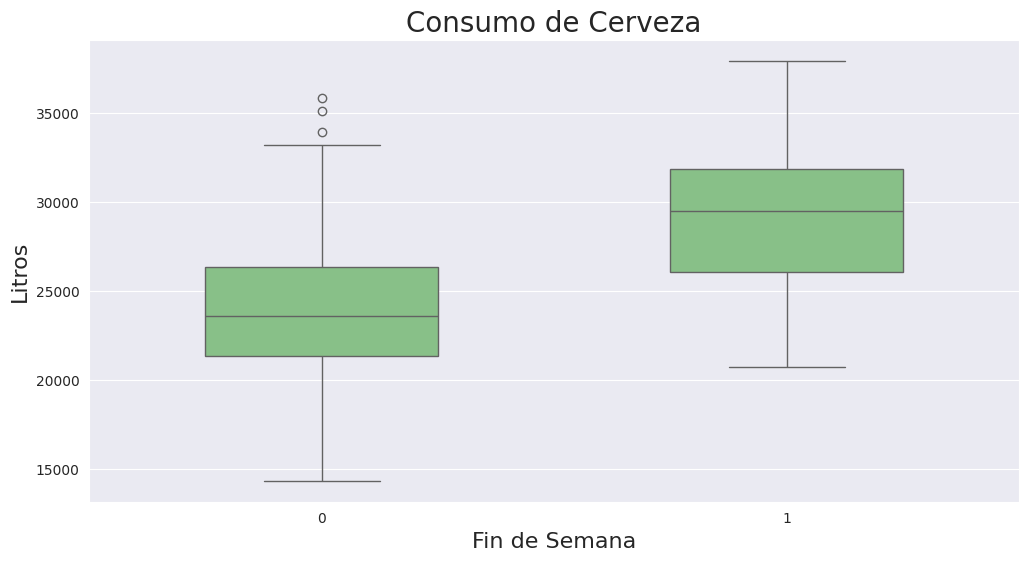

In [13]:
ax=sns.boxplot(y='consumo',x='fds',data=datos,orient='v',width=0.5)
ax.figure.set_size_inches(12,6)
ax.set_title('Consumo de Cerveza',fontsize=20)
ax.set_ylabel('Litros', fontsize=16)
ax.set_xlabel('Fin de Semana', fontsize=16)
ax

# <font color='red' style='font-size: 30px;'>Distribución de frecuencias (Histograma)</font>
<hr style='border: 2px solid red;'>

## Distribución de frecuencias de la variable *dependiente* (y)


https://seaborn.pydata.org/generated/seaborn.distplot.html?highlight=distplot#seaborn.distplot

<Axes: title={'center': 'Distribuición de Frecuencias'}, xlabel='consumo', ylabel='Consumo de Cerveza(Litros)'>

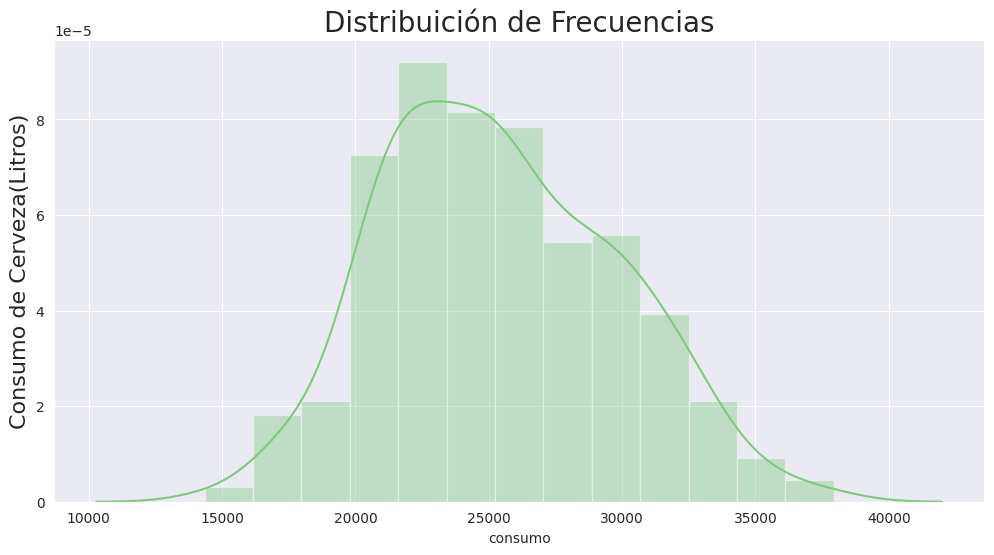

In [14]:
ax=sns.distplot(datos['consumo'])
ax.figure.set_size_inches(12,6)
ax.set_title('Distribuición de Frecuencias',fontsize=20)
ax.set_ylabel('Consumo de Cerveza(Litros)', fontsize=16)
ax

# <font color='red' style='font-size: 30px;'>Variable Dependiente X Variables Explicativas (pairplot)</font>
<hr style='border: 2px solid red;'>

## Gráficos de dispersión (scatterplots) entre las variables del dataset

## seaborn.pairplot

https://seaborn.pydata.org/generated/seaborn.pairplot.html?highlight=pairplot#seaborn.pairplot

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Grafica la relación entre pares de variables en un dataset.</p>

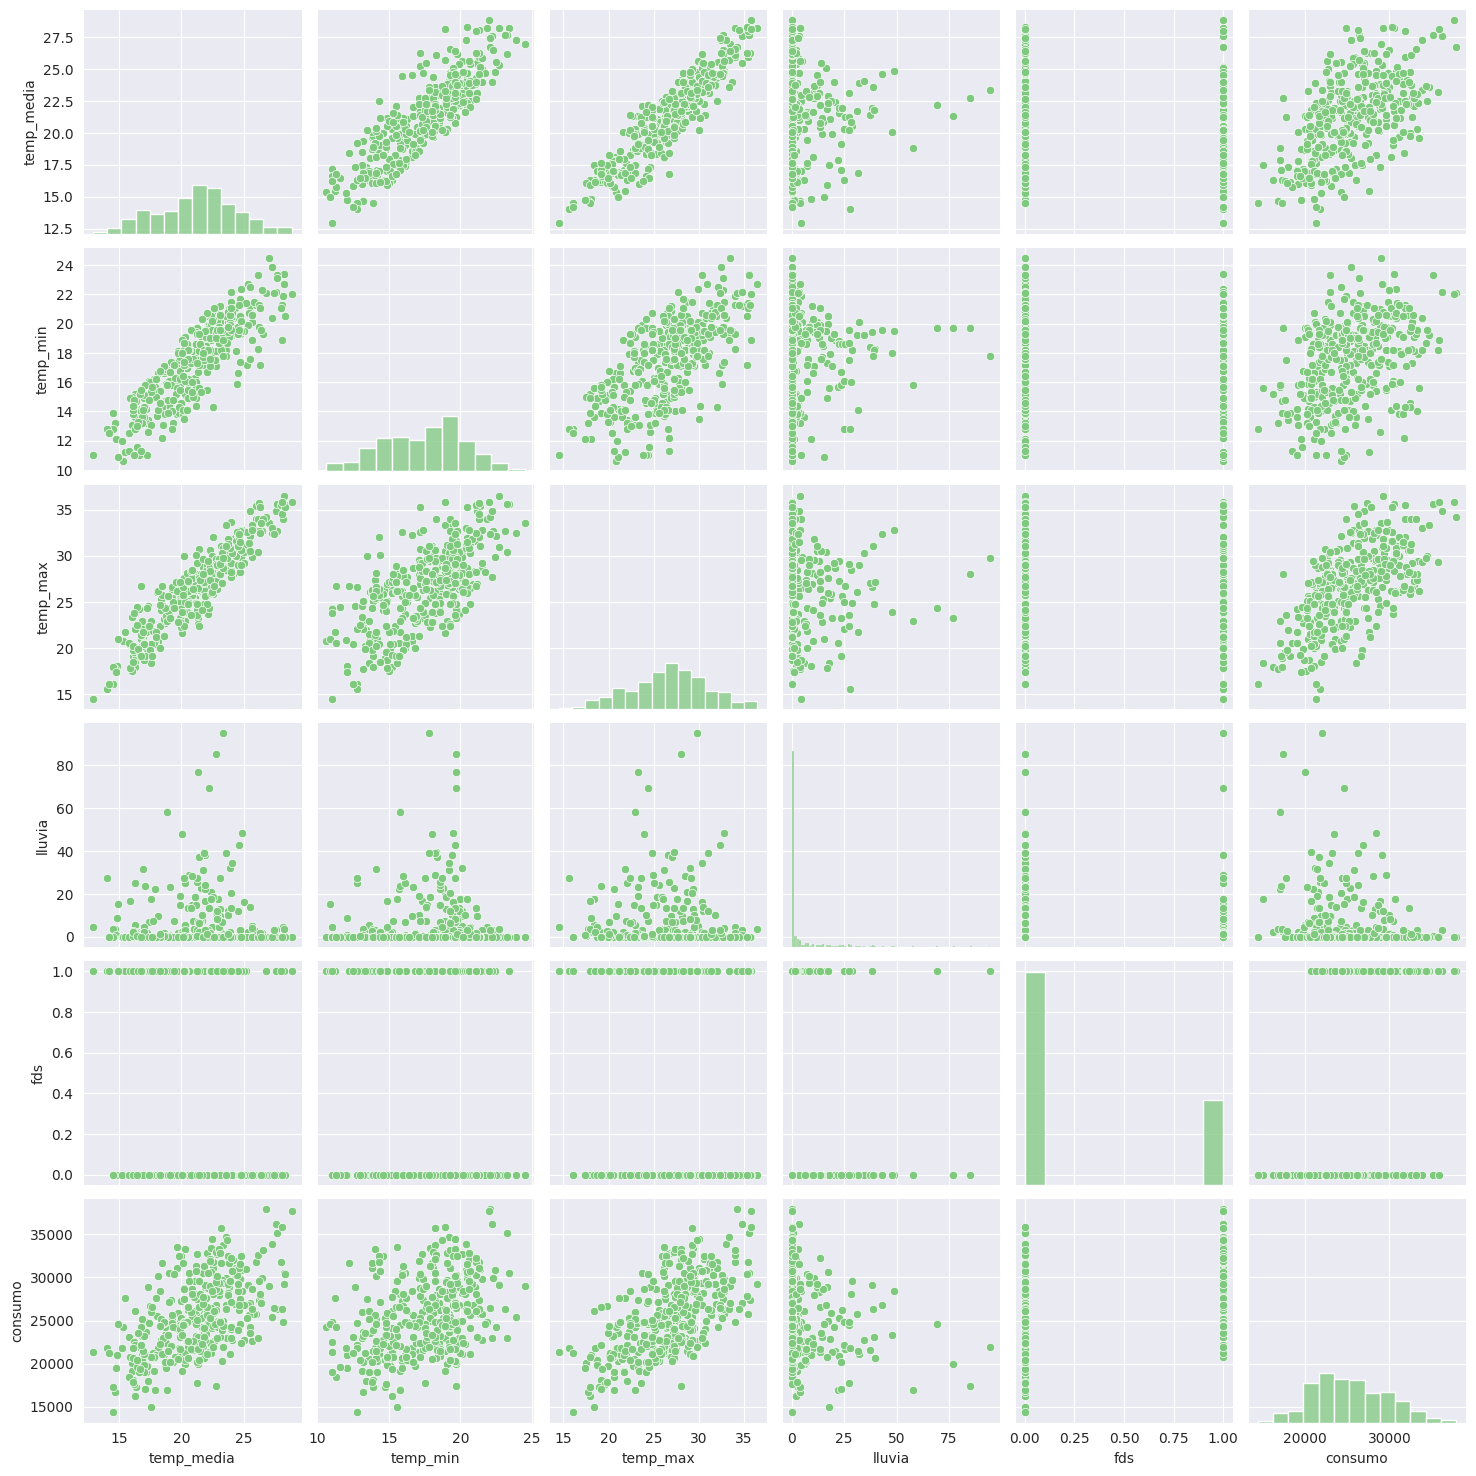

In [15]:
ax = sns.pairplot(datos)

## Graficar el pairplot fijando solo una variable en el eje y.

In [16]:
datos.columns

Index(['fecha', 'temp_media', 'temp_min', 'temp_max', 'lluvia', 'fds',
       'consumo'],
      dtype='object')

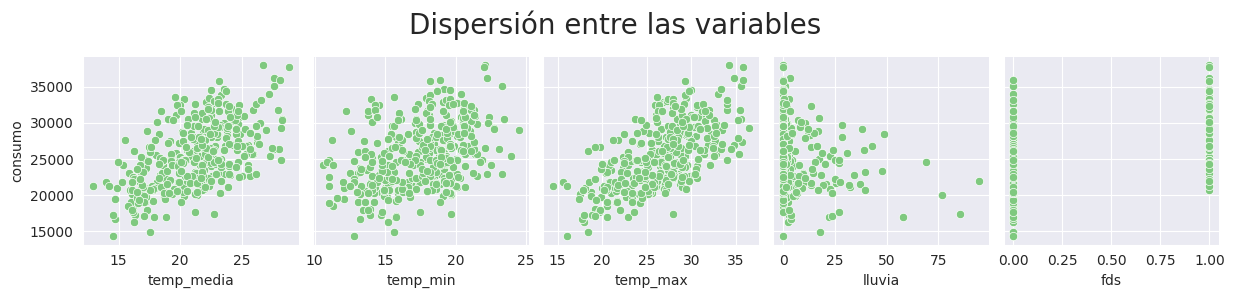

In [17]:
var_dependientes = ['temp_media', 'temp_min', 'temp_max', 'lluvia', 'fds']

ax = sns.pairplot(datos, y_vars='consumo', x_vars=var_dependientes,
                  diag_kind=None)
ax.fig.suptitle('Dispersión entre las variables', fontsize=20, y=1.15)
ax


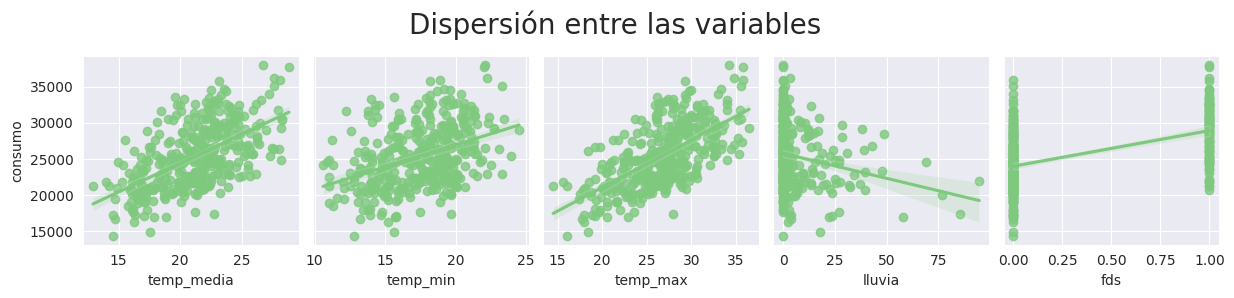

In [18]:
var_dependientes = ['temp_media', 'temp_min', 'temp_max', 'lluvia', 'fds']

ax = sns.pairplot(datos, y_vars='consumo', x_vars=var_dependientes,
                  diag_kind=None, kind='reg')
ax.fig.suptitle('Dispersión entre las variables', fontsize=20, y=1.15)
ax

# <font color='red' style='font-size: 30px;'>Variable Dependiente X Variables Explicativas (jointplot)</font>
<hr style='border: 2px solid red;'>

## seaborn.jointplot

https://seaborn.pydata.org/generated/seaborn.jointplot.html?highlight=jointplot#seaborn.jointplot

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Grafica la relación entre dos variables y sus respectivas distribuciones de frecuencia.</p>

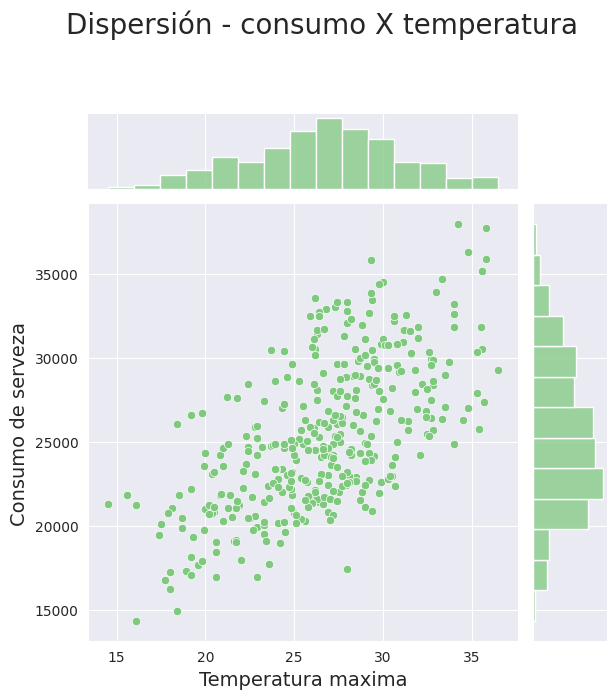

In [19]:
ax = sns.jointplot(x = 'temp_max', y = 'consumo', data=datos)
ax.fig.suptitle('Dispersión - consumo X temperatura', fontsize=20, y=1.15)
ax.set_axis_labels('Temperatura maxima', 'Consumo de serveza', fontsize=14)
ax

## Graficar un jointplot con la recta de regresión estimada

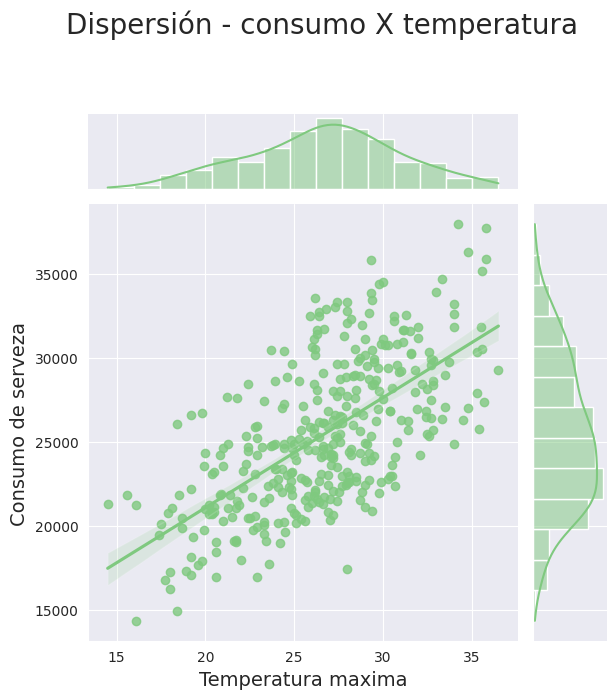

In [20]:
ax = sns.jointplot(x = 'temp_max', y = 'consumo', data=datos, kind='reg')
ax.fig.suptitle('Dispersión - consumo X temperatura', fontsize=20, y=1.15)
ax.set_axis_labels('Temperatura maxima', 'Consumo de serveza', fontsize=14)
ax

# <font color='red' style='font-size: 30px;'>Variable Dependiente X Variables Explicativas (lmplot)</font>
<hr style='border: 2px solid red;'>

## seaborn.lmplot

https://seaborn.pydata.org/generated/seaborn.lmplot.html?highlight=lmplot#seaborn.lmplot

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Trazar la recta de regresión entre dos variables junto con la dispersión entre ellas.</p>

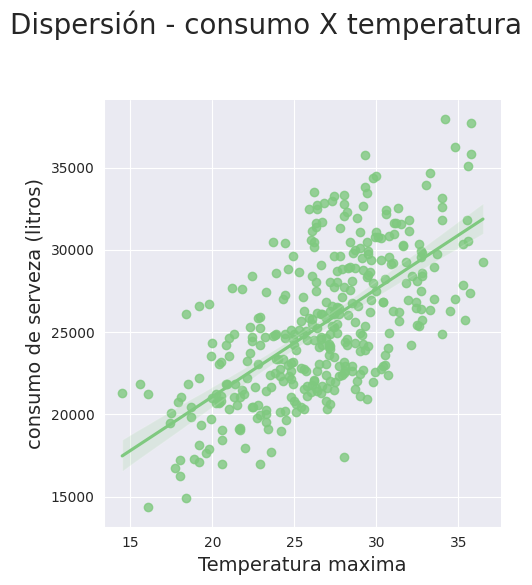

In [21]:
ax = sns.lmplot(x='temp_max', y='consumo', data=datos)
ax.fig.suptitle('Dispersión - consumo X temperatura', fontsize=20, y=1.15)
ax.set_xlabels('Temperatura maxima', fontsize=14)
ax.set_ylabels('consumo de serveza (litros)', fontsize=14)
ax

## Graficar un lmplot con una tercera variable en el análisis (tipo I).

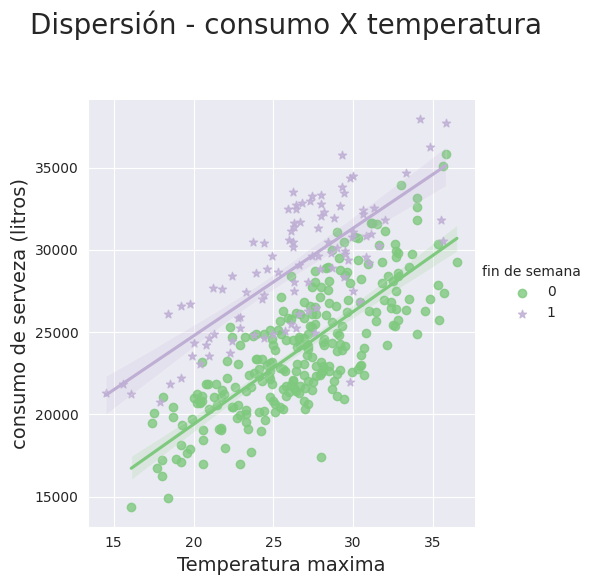

In [22]:
ax = sns.lmplot(x='temp_max', y='consumo', data=datos, hue='fds',
                markers=['o','*'], legend=False)
ax.fig.suptitle('Dispersión - consumo X temperatura', fontsize=20, y=1.15)
ax.set_xlabels('Temperatura maxima', fontsize=14)
ax.set_ylabels('consumo de serveza (litros)', fontsize=14)
ax.add_legend(title='fin de semana')
ax

## Graficar un lmplot con una tercera variable en el análisis (tipo II).

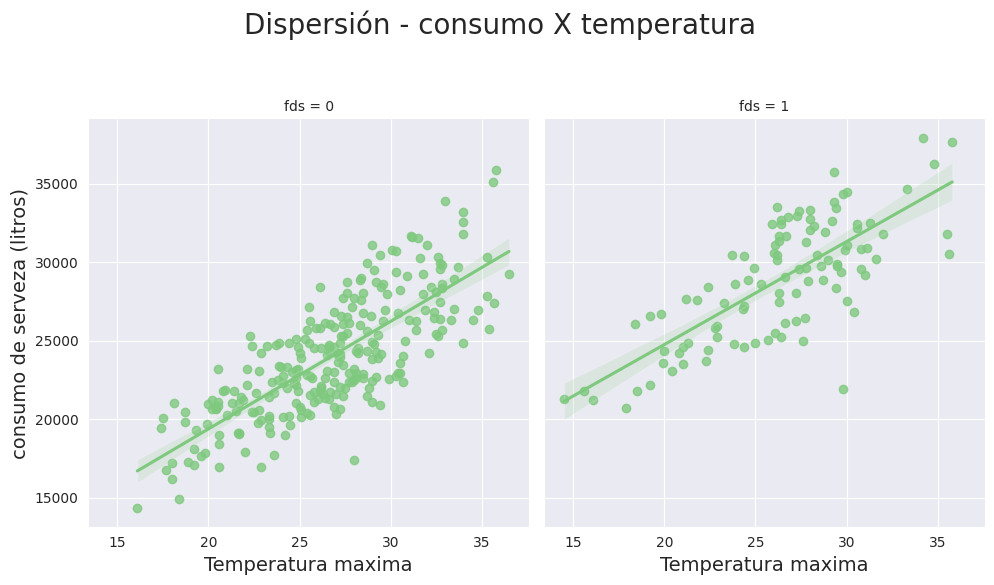

In [23]:
ax = sns.lmplot(x='temp_max', y='consumo', data=datos, col='fds')
ax.fig.suptitle('Dispersión - consumo X temperatura', fontsize=20, y=1.15)
ax.set_xlabels('Temperatura maxima', fontsize=14)
ax.set_ylabels('consumo de serveza (litros)', fontsize=14)
ax

# <font color='red' style='font-size: 30px;'>Estimando un Modelo de Regresión Lineal para el Consumo</font>
<hr style='border: 2px solid red;'>

# Regresión Lineal
<hr>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>El análisis de regresión se refiere al estudio de la dependencia de una variable (la variable <b> dependiente </b>) en relación con una o más variables (las variables <b> explicativas </b>) con el fin de estimar y/o predecir el valor medio de la primera en términos de los valores conocidos o fijos de estas últimas.</p>


## scikit-learn (https://scikit-learn.org/stable/)

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>El *scikit-learn* es un módulo de Python especializado en soluciones para *machine learning*.</p>



## Importando el *train_test_split* de la biblioteca *scikit-learn*

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [24]:
from sklearn.model_selection import train_test_split

## Creando una Series (pandas) para almacenar el Consumo de Cerveza (y).

In [25]:
y = datos['consumo']

## Creando un DataFrame (pandas) para almacenar las variables explicativas (X)

In [26]:
datos.columns

Index(['fecha', 'temp_media', 'temp_min', 'temp_max', 'lluvia', 'fds',
       'consumo'],
      dtype='object')

In [27]:
X = datos[['temp_max', 'lluvia', 'fds']]

## Creando los datasets de entrenamiento y de prueba

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2811)

## Comprobando los tamaños de los archivos generados por la función *train_test_split*.

In [29]:
X_train.shape

(255, 3)

In [30]:
X_test.shape

(110, 3)

In [31]:
y_train.shape

(255,)

In [32]:
y_test.shape

(110,)

In [33]:
X_train.shape[0] + X_test.shape[0]

365

In [34]:
X.shape[0]*0.3

109.5

In [35]:
X.shape[0]*0.7

255.49999999999997

<img width='1000px' src='https://caelum-online-public.s3.amazonaws.com/ESP-1774-regresion-lineal/reg_01.jpg'>

## Importando *LinearRegression* y *metrics* de la biblioteca *scikit-learn*

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

https://scikit-learn.org/stable/modules/classes.html#regression-metrics

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## Instanciando la clase *LinearRegression()*

In [37]:
modelo = LinearRegression()

## Utilizando el método *fit()* del objeto "modelo" para estimar nuestro modelo lineal con los datos de ENTRENAMIENTO (y_train e X_train)

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.fit

In [38]:
modelo.fit(X_train, y_train)

LinearRegression()

## Obteniendo el coeficiente de determinación (R²) del modelo estimado con los datos de ENTRENAMIENTO

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.score

### Coeficiente de Determinación - R²

El coeficiente de determinación (R²) es una medida de resumen que indica cuánto se ajusta la recta de regresión a los datos. Es un valor entre 0 y 1.

$$R^2(y, \hat{y}) = 1 - \frac {\sum_{i=0}^{n-1}(y_i-\hat{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y}_i)^2}$$

In [39]:
print('R²={}'.format(modelo.score(X_train, y_train).round(2)))

R²=0.73


## Generando predicciones para los datos de ENTRENAMIENTO (X_test) con el método *predict()* del objeto "modelo"

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict

In [40]:
y_predicho= modelo.predict(X_test)

## Obteniendo el coeficiente de determinación (R²) para las predicciones del nuestro modelo

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score

In [41]:
'''comprar los datos
y_test - los datos reales de nuestros datos
y_predicho - los datos que el modelo predijo

esto lo hacemos ocn el fin de saber que tan bien predice
nisetro modelo sobre nuestros datos
'''
print('R²={}'.format(metrics.r2_score(y_test, y_predicho).round(2)))

R²=0.69


# <font color='red' style='font-size: 30px;'>Obteniendo Predicciones Puntuales</font>
<hr style='border: 2px solid red;'>

## Datos de entrata

In [42]:
entrada = X_test[0:1]
entrada

,temp_max,lluvia,fds
5,30.5,12.2,0


## Generando predicción puntual

In [43]:
modelo.predict(entrada)[0]

26094.901775262017

## Creando un simulador simple

In [44]:
temp_max = 40
lluvia = 0
fds=1

entrada = [[temp_max, lluvia, fds]]
print('{} litros'.format(modelo.predict(entrada)[0].round(2)))

38742.53 litros


# <font color='red' style='font-size: 30px;'>Interpretación de los Coeficientes Estimados</font>
<hr style='border: 2px solid red;'>

<img width='1000px' src='https://caelum-online-public.s3.amazonaws.com/ESP-1774-regresion-lineal/reg_02.jpg'>

## Obteniendo el intercepto del modelo

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>El <b> intercepto </b> representa el efecto medio en $ Y $ (Consumo de cerveza) con todas las variables explicativas excluidas del modelo. Dicho de otra forma, el <b> intercepto </b> representa el efecto medio en $ Y $ (consumo de cerveza) cuando $ X_2 $ (temperatura máxima), $ X_3 $ (lluvia) y $ X_4 $ (fin de semana ) son iguales a cero.</p>

In [45]:
modelo.intercept_

5951.976339312445

## Obteniendo los coeficientes de regresión

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>Los <b> coeficientes de regresión </b> $\beta_2 $, $\beta_3 $ y $\beta_4 $ son conocidos como <b> coeficientes de regresión parcial </b> o <b> coeficientes angulares parciales </b> . Considerando el número de variables explicativas en nuestro modelo, su significado sería el siguiente: $ \beta_2 $ mide la variación en el valor medio de $ Y $ (Consumo de cerveza) por variación unitaria en $ X_2 $ (Temperatura máxima), manteniéndose constantes los valores de $ X_3 $ (Lluvia) y $ X_4 $ (Fin de semana). En otras palabras, $ \beta_2 $ nos da el efecto "directo" o "neto" de una unidad de variación en $ X_2 $ sobre el valor medio de $ Y $, excluyendo los efectos que pueden tener $ X_3 $ y $ X_4 $ en el promedio de $ Y $. Del mismo modo podemos interpretar los demás coeficientes de regresión.</p>

In [46]:
modelo.coef_

array([ 684.73675898,  -60.7824355 , 5401.08333866])

## Confirmando el orden de las variables explicativas en el DataFrame

In [47]:
X.columns

Index(['temp_max', 'lluvia', 'fds'], dtype='object')

## Creando una lista de nombres de las variables del modelo

In [48]:
index = ['Intercepto', 'Tempereatura maxima', 'Lluvia (mm)', 'Fin de semana']

## Creando un DataFrame para almacenar los coeficientes del modelo

https://docs.scipy.org/doc/numpy/reference/generated/numpy.append.html?#numpy.append

In [49]:
pd.DataFrame(data=np.append(modelo.intercept_, modelo.coef_), index= index, columns=['Parametros'])

,Parametros
Intercepto,5951.976339
Tempereatura maxima,684.736759
Lluvia (mm),-60.782435
Fin de semana,5401.083339


## Interpretación de los coeficientes estimados

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>
<b>Intercepto</b> → Excluyendo el efecto de las variables explicativas ($ X_2 = X_3 = X_4 = 0 $) el efecto medio en el Consumo de Cerveza sería <b> 5951,98 litros</b>.
</p>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>
<b>Temperatura Máxima (°C) </b> → Manteniendo constantes los valores de $ X_3 $ (Lluvia) y $ X_4 $ (Fin de Semana), el aumento de 1°C en la Temperatura Máxima genera una variación media en el Consumo de Cerveza de <b> 684,74 litros</b>.
</p>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>
<b>Lluvia (mm) </b> → Manteniendo constantes los valores de $ X_2 $ (Temperatura Máxima) y $ X_4 $ (Fin de Semana), la adición de 1 mm de Lluvia genera una variación media en el Consumo de Cerveza de <b > -60,78 litros</b>.
</p>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>
<b>Fin de semana (Sí / No) </b> → Manteniendo constantes los valores de $ X_2 $ (Temperatura máxima) y $ X_3 $ (Lluvia), el hecho de que el día se clasifique como Fin de semana genera una variación media en el consumo de cerveza de <b> 5401,08 litros</b>.
</p>

# <font color='red' style='font-size: 30px;'>Análisis gráfico de las predicciones del modelo</font>
<hr style='border: 2px solid red;'>

## Generando predicciones del modelo para los datos de ENTRENAMIENTO

In [50]:
y_predicho_train=modelo.predict(X_train)

## Gráfico de dispersión entre valor estimado y valor real

https://seaborn.pydata.org/generated/seaborn.scatterplot.html

<Axes: title={'center': 'Predicción X Real'}, xlabel='Consumo de Cerveza (litros) - Predicción', ylabel='Consumo de Cerveza (litros) - Real'>

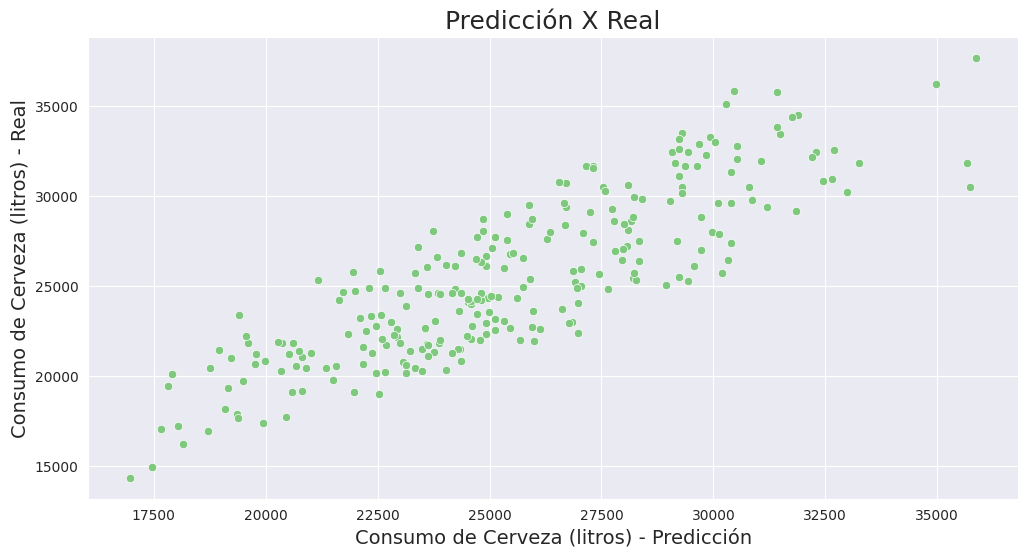

In [51]:
ax=sns.scatterplot(x=y_predicho_train, y=y_train)
ax.figure.set_size_inches(12, 6)
ax.set_title('Predicción X Real', fontsize=18)
ax.set_xlabel('Consumo de Cerveza (litros) - Predicción', fontsize=14)
ax.set_ylabel('Consumo de Cerveza (litros) - Real', fontsize=14)
ax

## Obteniendo los residuos

In [52]:
residuo=y_train - y_predicho_train

## Gráfico de dispersión entre valor estimado y residuos

Método informal para verificar la hipótesis de varianza constante de los residuos (homocedasticidad)

<Axes: title={'center': 'Predicción X Real'}, xlabel='Consumo de Cerveza (litros) - Predicción', ylabel='Consumo de Cerveza (litros) - Real'>

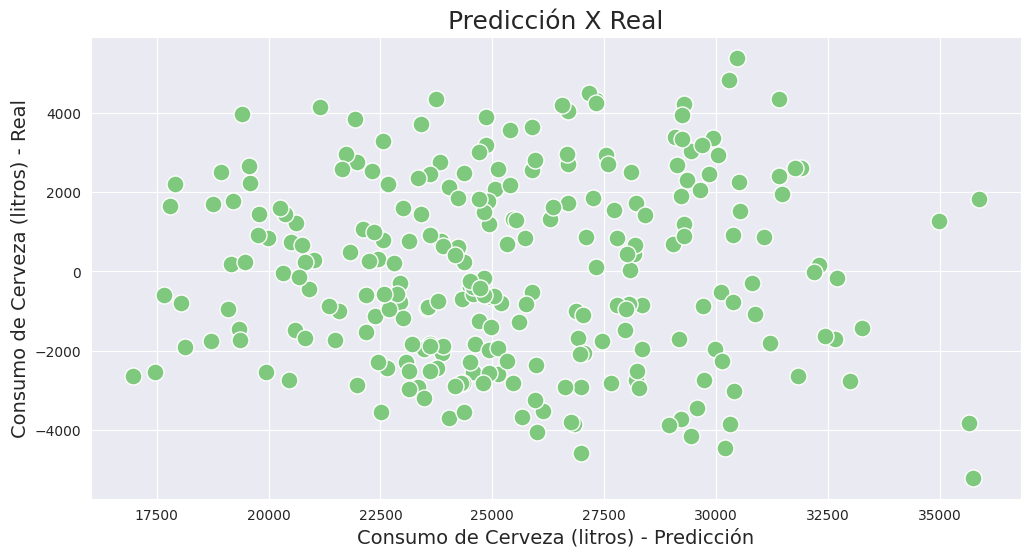

In [53]:
ax=sns.scatterplot(x=y_predicho_train, y=residuo, s=150)
ax.figure.set_size_inches(12, 6)
ax.set_title('Predicción X Real', fontsize=18)
ax.set_xlabel('Consumo de Cerveza (litros) - Predicción', fontsize=14)
ax.set_ylabel('Consumo de Cerveza (litros) - Real', fontsize=14)
ax

## Usando los residuos al cuadrado

<img width='1500px' src='https://caelum-online-public.s3.amazonaws.com/ESP-1774-regresion-lineal/var_u.jpg'>
Fuente: Econometria Básica - 5ª edición - Gujarati y Porter

<Axes: title={'center': 'Predicción X Real'}, xlabel='Consumo de Cerveza (litros) - Predicción', ylabel='Consumo de Cerveza (litros) - Real'>

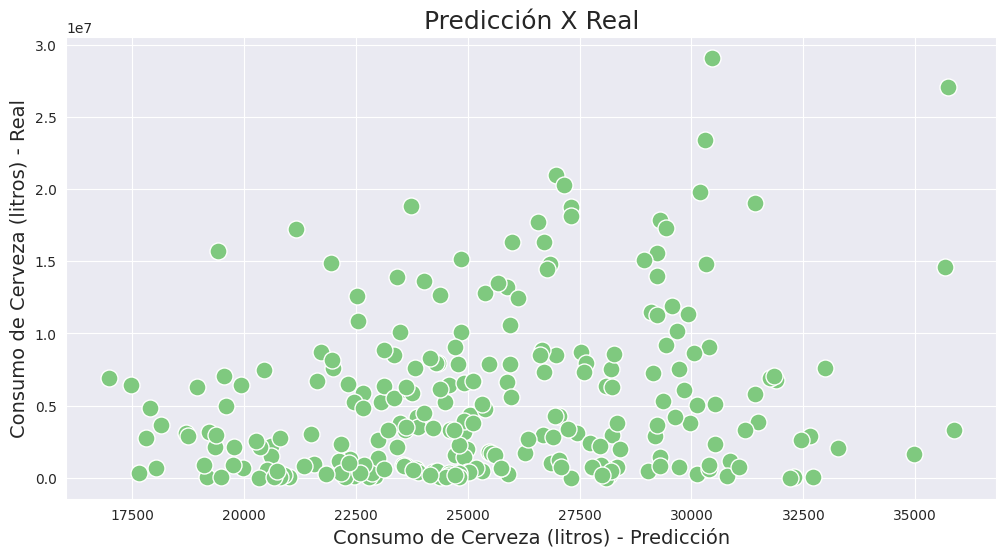

In [54]:
ax=sns.scatterplot(x=y_predicho_train, y=residuo**2, s=150)
ax.figure.set_size_inches(12, 6)
ax.set_title('Predicción X Real', fontsize=18)
ax.set_xlabel('Consumo de Cerveza (litros) - Predicción', fontsize=14)
ax.set_ylabel('Consumo de Cerveza (litros) - Real', fontsize=14)
ax

## Graficando la distribuición de frecuencias de los residuos

<Axes: title={'center': 'Distribuición de Frecuencias de los Residuos'}, xlabel='Litros', ylabel='Density'>

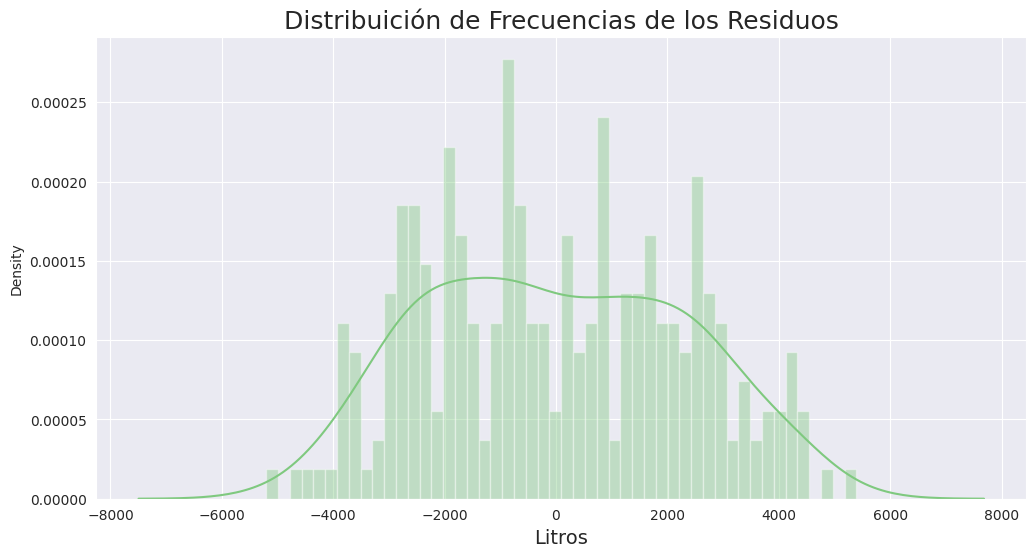

In [55]:
ax=sns.distplot(residuo,bins=50)
ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuición de Frecuencias de los Residuos', fontsize=18)
ax.set_xlabel('Litros', fontsize=14)
ax

# <font color='red' style='font-size: 30px;'>Comparando Modelos</font>


<hr style='border: 2px solid red;'>

## Estimación de un nuevo modelo con la sustitución de la variable explicativa Temperatura máxima por Temperatura media.

In [56]:
X2=datos[['temp_media', 'lluvia', 'fds']]

## Creando los datasets de entrenamiento y de prueba

In [57]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.3, random_state=2811)

## Instanciar la clase *LinearRegression()*

In [58]:
modelo_2=LinearRegression()

## Usando el método *fit()* del objeto "modelo_2" para estimar nuestro modelo lineal con los datos de ENTRENAMIENTO (y2_train e X2_train)

In [59]:
modelo_2.fit(X2_train, y2_train)

LinearRegression()

## Obteniendo el coeficiente de determinación (R²) del nuevo modelo estimado y comparando con el resultado del modelo anterior

In [60]:
print('Modelo com temp. media')
print('R²={}'.format(modelo_2.score(X2_train, y2_train).round(2)))

Modelo com temp. media
R²=0.66


In [61]:
print('Modelo com temp. maxima')
print('R²={}'.format(modelo.score(X_train, y_train).round(2)))

Modelo com temp. maxima
R²=0.73


## Generando predicciones para los datos de PRUEBA (X_test e X2_test) con el método *predict()* de los objetos "modelo" e "modelo_2"

In [62]:
y_predicho_2=modelo_2.predict(X2_test)

## Obteniendo el coeficiente de determinación (R²) para las predicciones de los dos modelos

In [63]:
print('Modelo com temp. media')
print('R²={}'.format(metrics.r2_score(y2_test, y_predicho_2).round(2)))

Modelo com temp. media
R²=0.66


In [64]:
print('Modelo com temp. maxima')
print('R²={}'.format(metrics.r2_score(y_test, y_predicho).round(2)))

Modelo com temp. maxima
R²=0.69


# <font color='red' style='font-size: 30px;'>Otras Métricas de Regresión</font>
<hr style='border: 2px solid red;'>

## Métricas da regresión
<hr>

fonte: https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics

Algunas estadísticas obtenidas del modelo de regresión son muy útiles como criterio para comparar varios modelos estimados y seleccionar el mejor modelo. Las principales métricas de regresión que scikit-learn pone a disposición para los modelos lineales son las siguientes:

### Error Cuadrático Medio

Media de los cuadrados de los errores. Los mejores ajustes tienen un $EQM$ más bajo.

$$EQM(y, \hat{y}) = \frac 1n\sum_{i=0}^{n-1}(y_i-\hat{y}_i)^2$$

### Raíz del Error Cuadrático Medio

Raíz cuadrada de la media de los cuadrados de los errores. Los mejores ajustes tienen un $\sqrt{EQM}$ más bajo.

$$\sqrt{EQM(y, \hat{y})} = \sqrt{\frac 1n\sum_{i=0}^{n-1}(y_i-\hat{y}_i)^2}$$



## Obteniendo métricas para el modelo con Temperatura Media

In [65]:
EQM_2=metrics.mean_squared_error(y2_test, y_predicho_2).round(2)
REQM_2 = np.sqrt(EQM_2).round(2)
R2_2 = metrics.r2_score(y2_test, y_predicho_2).round(2)

pd.DataFrame([EQM_2, REQM_2, R2_2], ['EQM_2', 'REQM_2', 'R2_2'],
             columns = ['Metricas'])

,Metricas
EQM_2,6060775.46
REQM_2,2461.86
R2_2,0.66


## Obteniendo métricas para el modelo con Temperatura Máxima

In [66]:
EQM = metrics.mean_squared_error(y_test, y_predicho).round(2)
REQM = np.sqrt(EQM).round(2)
R2 = metrics.r2_score(y_test, y_predicho).round(2)

pd.DataFrame([EQM, REQM, R2], ['EQM', 'REQM', 'R2'],
             columns = ['Metricas'])

,Metricas
EQM,5471976.38
REQM,2339.23
R2,0.69


# <font color='red' style='font-size: 30px;'>Guardando y cargando el modelo estimado</font>
<hr style='border: 2px solid red;'>

## Datos de entrada

In [67]:
X_test[0:1]

,temp_max,lluvia,fds
5,30.5,12.2,0


In [69]:
entrada=X_test[0:1]

## Generando predicción puntual

In [70]:
modelo.predict(entrada)[0]

26094.901775262017

## Creando un simulador simple

In [71]:
temp_max=30.5
lluvia=12.2
fds=0
entrada=[[temp_max, lluvia, fds]]

print('{} litros'.format(modelo.predict(entrada)[0].round(2)))

26094.9 litros


## Guardando el modelo estimado

## pickle (https://docs.python.org/3/library/pickle.html)

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>El módulo <b> pickle </b> implementa protocolos binarios para serializar y deserializar la estructura de un objeto Python.</p>

In [72]:
import pickle

In [74]:
# Abre un archivo llamado 'modelo_consumo_cerveza'
# en modo de escritura de bytes ('wb').
output = open('modelo_consumo_cerveza', 'wb')

# Utiliza la función dump del módulo pickle para serializar
# el objeto llamado 'modelo'
# y guardar la representación serializada en el archivo abierto.
pickle.dump(modelo, output)

# Cierra el archivo.
output.close()

### En un nuevo notebook/proyeto Python

<h4 style='color: blue; font-weight: normal'>In [1]:</h4>

```sh
import pickle

modelo = open('modelo_consumo_cerveza','rb')
lm_new = pickle.load(modelo)
modelo.close()

temp_max = 30.5
chuva = 12.2
fds = 0
entrada = [[temp_max, lluvia, fds]]
print('{0:.2f} litros'.format(lm_new.predict(entrada)[0]))
```

<h4 style='color: red; font-weight: normal'>Out [1]:</h4>

```
26094.90 litros
```